## Data Understanding Report


In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

**1) Load the Dataset**

In [7]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\archive (2)\Balaji Fast Food Sales.csv")

In [8]:
df

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


In [9]:
df.columns.tolist()

['order_id',
 'date',
 'item_name',
 'item_type',
 'item_price',
 'quantity',
 'transaction_amount',
 'transaction_type',
 'received_by',
 'time_of_sale']

**2) Inspect the Data**

In [10]:
# check Dataset Shape(Rows & Columns)
df.shape

(1000, 10)

In [11]:
# View first 5 rows
df.head()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,07-03-2022,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,8/23/2022,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,11/20/2022,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,02-03-2023,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,10-02-2022,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening


In [12]:
# View last 5 rows
df.tail()

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
995,996,3/19/2023,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,9/20/2022,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,1/26/2023,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,8/27/2022,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon
999,1000,5/29/2022,Aalopuri,Fastfood,20,3,60,Online,Mrs.,Midnight


**Columns of the Dataset**

In [13]:
df.columns

Index(['order_id', 'date', 'item_name', 'item_type', 'item_price', 'quantity',
       'transaction_amount', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='object')

**Checking Summary Statistics of Numerical Columns**

In [14]:
df.describe()

,order_id,item_price,quantity,transaction_amount
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,33.315000,8.162000,275.230000
std,288.819436,14.921744,4.413075,204.402979
min,1.000000,20.000000,1.000000,20.000000
25%,250.750000,20.000000,4.000000,120.000000
50%,500.500000,25.000000,8.000000,240.000000
75%,750.250000,50.000000,12.000000,360.000000
max,1000.000000,60.000000,15.000000,900.000000


**Checking Summary Statistics of Categorical Column**

In [15]:
df.describe(include='O')

,date,item_name,item_type,transaction_type,received_by,time_of_sale
count,1000,1000,1000,893,1000,1000
unique,348,7,2,2,2,5
top,05-09-2022,Cold coffee,Fastfood,Cash,Mr.,Night
freq,8,161,686,476,512,205


**Checking Structure of the Dataset**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


**3) Data Cleaning**

**Checking Missing Values**

In [17]:
df.isnull().sum()

order_id                0
date                    0
item_name               0
item_type               0
item_price              0
quantity                0
transaction_amount      0
transaction_type      107
received_by             0
time_of_sale            0
dtype: int64

**Checking Duplicates**

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
## Handling missing values
df['transaction_type'] = df['transaction_type'].fillna(0)

In [20]:
df['transaction_type']

0           0
1        Cash
2        Cash
3      Online
4      Online
        ...  
995         0
996         0
997         0
998         0
999    Online
Name: transaction_type, Length: 1000, dtype: object

In [21]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [22]:
# We don't have any duplicate values, if incase we have duplicate values in our dataset we have to remove
# df.drop_duplicates(inplace=True)

**4) Data Manipulation**

In [23]:
df['date'] = df['date'].str.replace('/','-')

In [24]:
df['date'].unique()

array(['07-03-2022', '8-23-2022', '11-20-2022', '02-03-2023',
       '10-02-2022', '11-14-2022', '05-03-2022', '12-22-2022',
       '06-10-2022', '9-16-2022', '12-01-2022', '07-12-2022',
       '11-25-2022', '4-14-2022', '10-16-2022', '11-05-2022', '8-22-2022',
       '9-15-2022', '12-21-2022', '10-04-2022', '5-26-2022', '02-11-2023',
       '8-31-2022', '8-18-2022', '10-12-2022', '01-06-2023', '02-10-2023',
       '1-28-2023', '9-14-2022', '05-06-2022', '02-05-2023', '02-04-2023',
       '5-22-2022', '07-02-2022', '01-05-2023', '03-08-2023', '5-14-2022',
       '11-13-2022', '05-09-2022', '8-28-2022', '8-15-2022', '05-07-2022',
       '07-10-2022', '2-23-2023', '11-06-2022', '11-02-2022', '5-16-2022',
       '3-16-2023', '7-26-2022', '12-28-2022', '11-23-2022', '08-04-2022',
       '07-01-2022', '06-11-2022', '12-25-2022', '10-17-2022',
       '12-09-2022', '7-25-2022', '04-05-2022', '5-15-2022', '12-17-2022',
       '01-10-2023', '12-05-2022', '03-09-2023', '7-29-2022',
       '02-02

In [25]:
# Fix Data Types
df['date'] = pd.to_datetime(df['date'], errors = 'coerce')

In [26]:
df['date'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: date
Non-Null Count  Dtype         
--------------  -----         
1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 7.9 KB


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   object        
 3   item_type           1000 non-null   object        
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   object        
 8   received_by         1000 non-null   object        
 9   time_of_sale        1000 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(5)
memory usage: 78.3+ KB


In [28]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include = ['object']).columns

In [29]:
categorical_cols

Index(['item_name', 'item_type', 'transaction_type', 'received_by',
       'time_of_sale'],
      dtype='object')

In [30]:
# convert all objects into categorical
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   category      
 3   item_type           1000 non-null   category      
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   category      
 8   received_by         1000 non-null   category      
 9   time_of_sale        1000 non-null   category      
dtypes: category(5), datetime64[ns](1), int64(4)
memory usage: 45.0 KB


In [32]:
## dividing the dates , months, years

In [33]:
df['date']

0     2022-07-03
1     2022-08-23
2     2022-11-20
3     2023-02-03
4     2022-10-02
         ...    
995   2023-03-19
996   2022-09-20
997   2023-01-26
998   2022-08-27
999   2022-05-29
Name: date, Length: 1000, dtype: datetime64[ns]

In [34]:
df['year'] = df['date'].dt.year
df['year']

0      2022
1      2022
2      2022
3      2023
4      2022
       ... 
995    2023
996    2022
997    2023
998    2022
999    2022
Name: year, Length: 1000, dtype: int32

In [35]:
df['date_month'] = df['date'].dt.month
df['date_month'] 

0       7
1       8
2      11
3       2
4      10
       ..
995     3
996     9
997     1
998     8
999     5
Name: date_month, Length: 1000, dtype: int32

In [36]:
df['date_day'] = df['date'].dt.day
df['date_day']

0       3
1      23
2      20
3       3
4       2
       ..
995    19
996    20
997    26
998    27
999    29
Name: date_day, Length: 1000, dtype: int32

<Axes: >

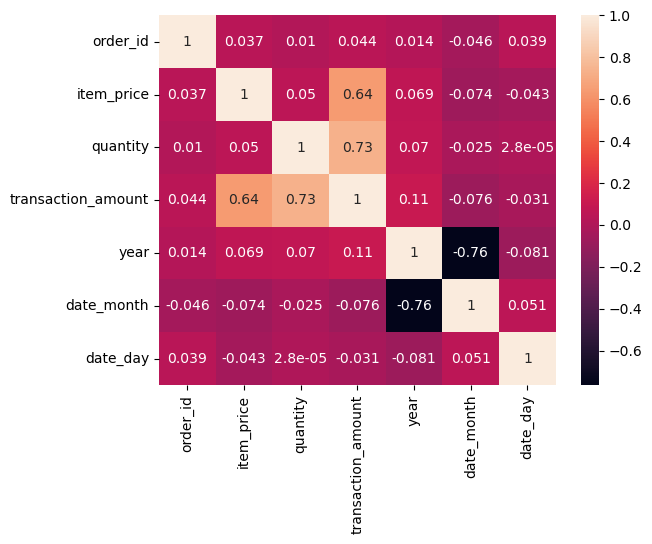

In [37]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

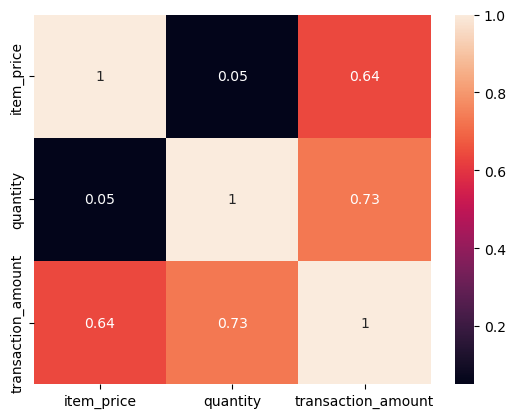

In [38]:
df1 = df[['item_price','quantity','transaction_amount']]
sns.heatmap(df1.corr(), annot = True)
plt.show()

In [39]:
numerical_cols = df.select_dtypes(include = ['int']).columns
numerical_cols

Index(['order_id', 'item_price', 'quantity', 'transaction_amount', 'year',
       'date_month', 'date_day'],
      dtype='object')

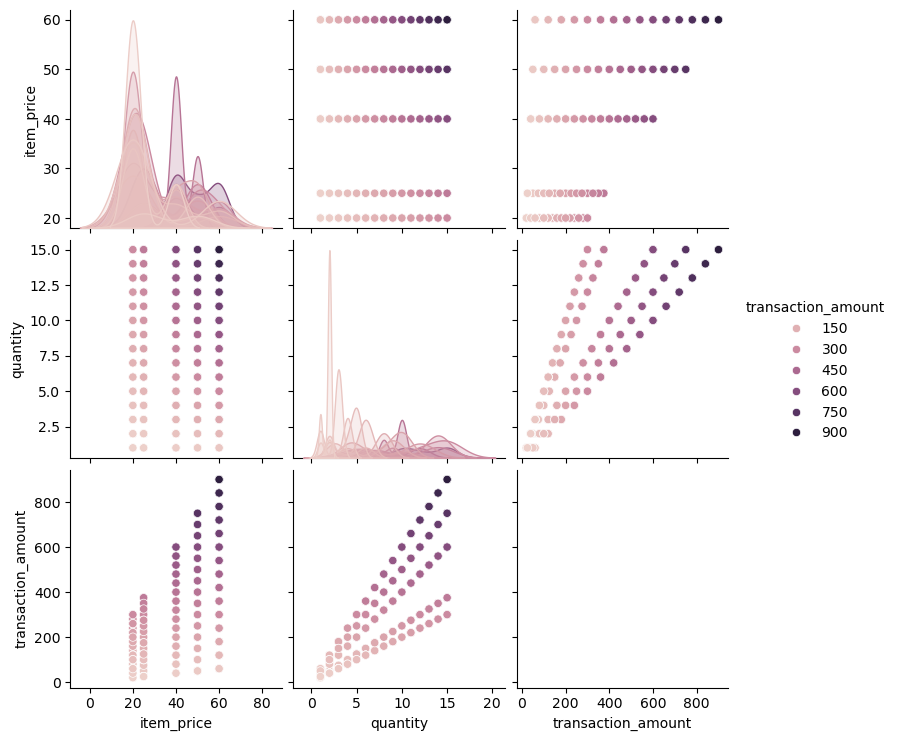

In [40]:
sns.pairplot(df, vars = ['item_price','quantity', 'transaction_amount'],
             hue = 'transaction_amount')
plt.show()

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            1000 non-null   int64         
 1   date                1000 non-null   datetime64[ns]
 2   item_name           1000 non-null   category      
 3   item_type           1000 non-null   category      
 4   item_price          1000 non-null   int64         
 5   quantity            1000 non-null   int64         
 6   transaction_amount  1000 non-null   int64         
 7   transaction_type    1000 non-null   category      
 8   received_by         1000 non-null   category      
 9   time_of_sale        1000 non-null   category      
 10  year                1000 non-null   int32         
 11  date_month          1000 non-null   int32         
 12  date_day            1000 non-null   int32         
dtypes: category(5), datetime64[ns](1), int32(3), int6

**5) Univariate Analysis**

**Numerical Columns**

-- item_price, quantity, transaction_amount

**Ctegorical Columns**

--item_name, item_type, transaction_type, received_by, time_of_sale

In [42]:
# summary statistics
df['item_price'].describe()

count    1000.000000
mean       33.315000
std        14.921744
min        20.000000
25%        20.000000
50%        25.000000
75%        50.000000
max        60.000000
Name: item_price, dtype: float64

In [36]:
df['quantity'].describe()   # optional

count    1000.000000
mean        8.162000
std         4.413075
min         1.000000
25%         4.000000
50%         8.000000
75%        12.000000
max        15.000000
Name: quantity, dtype: float64

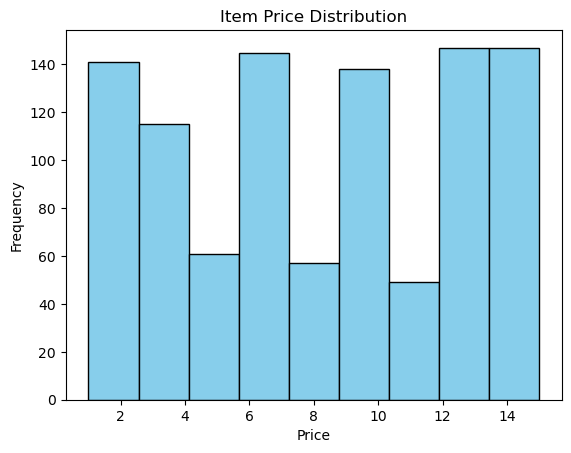

In [37]:
# Histogram: shows distribution

plt.hist(df['quantity'], bins = 9, color='skyblue',edgecolor = 'black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Item Price Distribution',color = 'black')
plt.show()

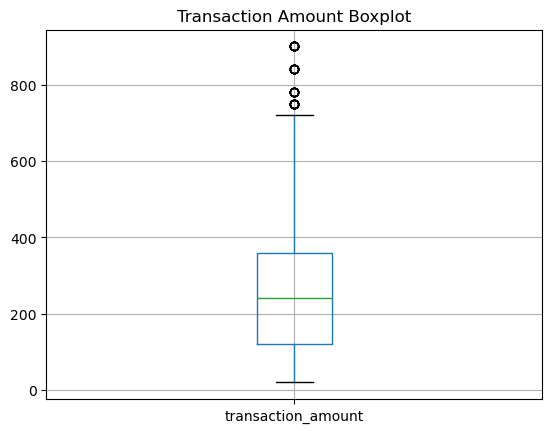

In [38]:
# boxplot: Detect outliers
df.boxplot(column = 'transaction_amount')
plt.title('Transaction Amount Boxplot')
plt.show()

In [39]:
# categorical
# item_name, item_type, transaction_type, received_by, time_of_sale

In [40]:
df['item_type'].value_counts()

item_type
Fastfood     686
Beverages    314
Name: count, dtype: int64

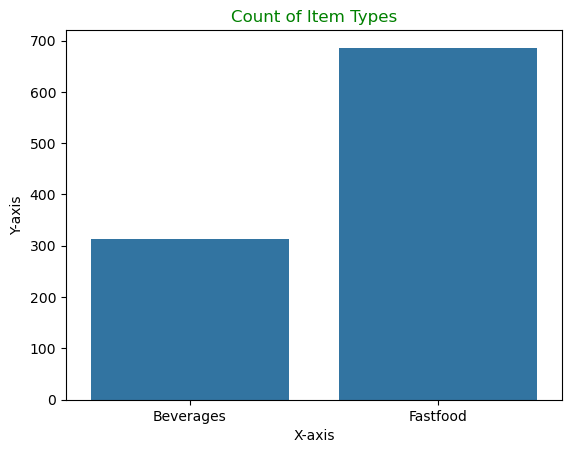

In [45]:
# Countplot: frequency visualization

sns.countplot(x='item_type',data=df)
plt.title("Count of Item Types", color = 'green')
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [ ]:
df['item_name'].value_counts()

In [ ]:
sns.countplot(x='item_name',data=df)
plt.title("Number of orders per Item", color = 'green')
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [ ]:
counts = df['transaction_type'].value_counts()
counts

# pie plot

plt.pie(counts, autopct = '%1.1f%%',startangle=90)
plt.legend(counts.index)
plt.show()

In [ ]:
counts = df['time_of_sale'].value_counts()
counts

# pie chart

plt.pie(counts, autopct = '%1.1f%%',startangle=90)
plt.legend(counts.index)
plt.show()

In [125]:
# received by 
df['received_by'].value_counts()

received_by
Mr.     512
Mrs.    488
Name: count, dtype: int64

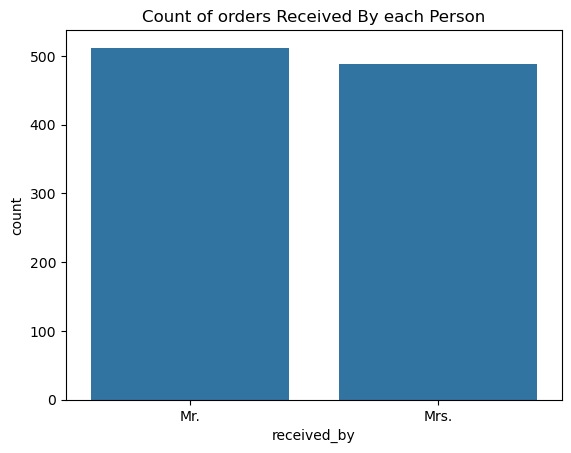

In [126]:
sns.countplot(x='received_by', data=df)
plt.title("Count of orders Received By each Person")
plt.show()

**6) Bivariate Analysis**

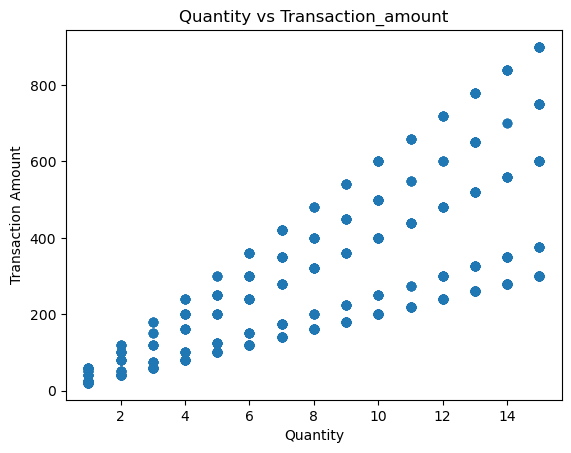

In [127]:
# Numerical vs Numerical

plt.scatter(df['quantity'], df['transaction_amount'])
plt.title("Quantity vs Transaction_amount")
plt.xlabel("Quantity")
plt.ylabel("Transaction Amount")
plt.show()

In [128]:
# check correlation
df[['quantity','transaction_amount']].corr()

,quantity,transaction_amount
quantity,1.000000,0.731806
transaction_amount,0.731806,1.000000


In [129]:
# Categorical vs Numerical
-- item_type vs transaction_amount
-- transaction_type vs quantity
-- time of sale vs transaction amount

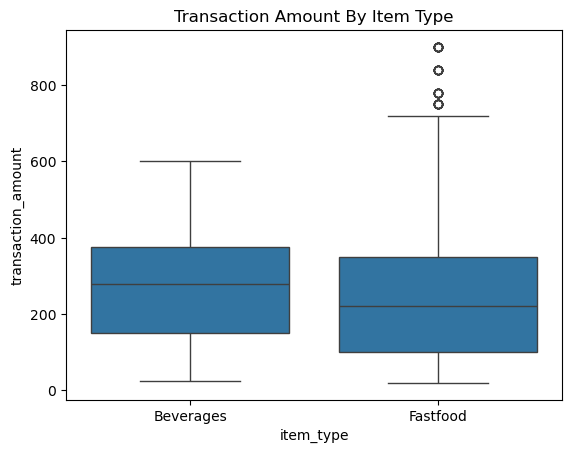

In [135]:
# item_type vs transaction_amount
sns.boxplot(x='item_type',y='transaction_amount',data=df)
plt.title("Transaction Amount By Item Type")
plt.show()

In [ ]:
# transaction_type vs quantity

In [139]:
df.groupby('transaction_type', observed = True)['quantity'].describe()

,count,mean,std,min,25%,50%,75%,max
transaction_type,,,,,,,,
0,107.0,8.672897,4.588286,1.0,4.5,9.0,13.0,15.0
Cash,476.0,8.283613,4.318555,1.0,5.0,8.0,12.0,15.0
Online,417.0,7.892086,4.466796,1.0,4.0,8.0,12.0,15.0


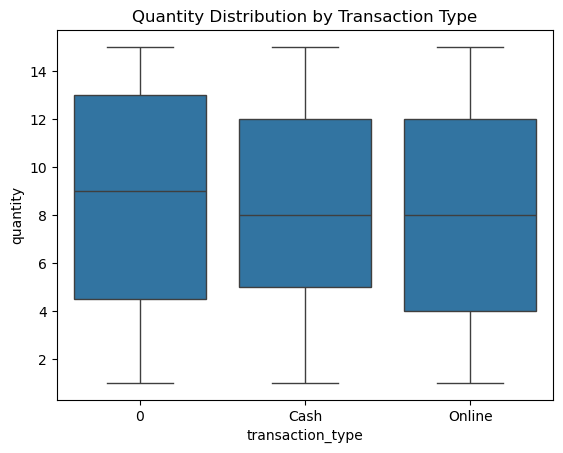

In [145]:
sns.boxplot(x='transaction_type',y='quantity', data=df)
plt.title("Quantity Distribution by Transaction Type")
plt.show()

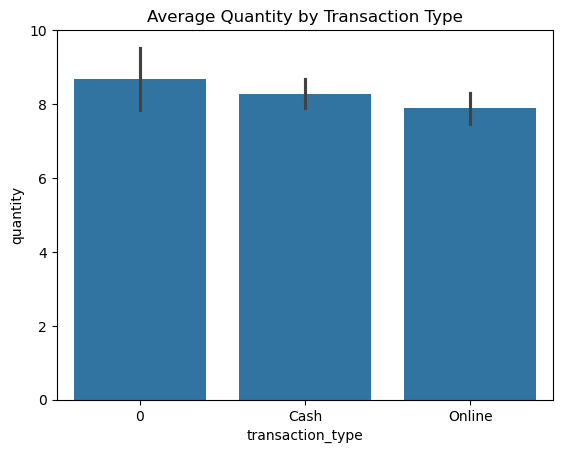

In [146]:
# bar plot
sns.barplot(x='transaction_type',y='quantity', data=df)
plt.title("Average Quantity by Transaction Type")
plt.show()

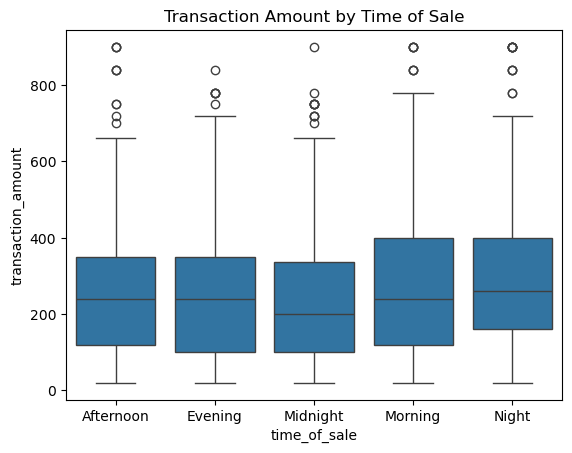

In [148]:
# time of sale vs transaction amount
sns.boxplot(x='time_of_sale',y='transaction_amount', data=df)
plt.title("Transaction Amount by Time of Sale")
plt.show()

In [ ]:
## categorical vs categorical
-- item_type vs transaction_type
-- time_of_sale vs transaction_type
-- received_by vs transaction_type

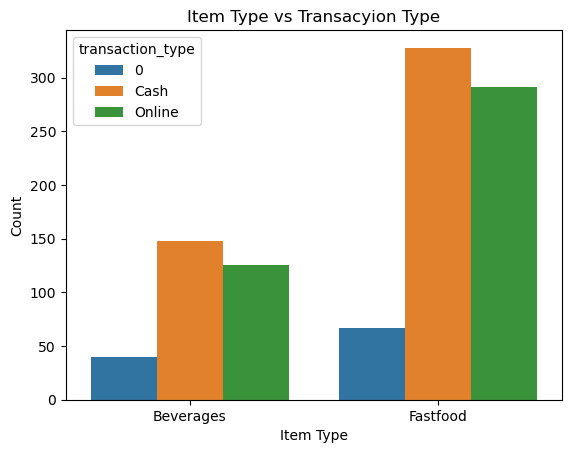

In [151]:
# item_type vs transaction_type

sns.countplot(x='item_type', hue ='transaction_type', data=df)
plt.title("Item Type vs Transacyion Type")
plt.xlabel("Item Type")
plt.ylabel("Count")
plt.show()

In [152]:
pd.crosstab(df['item_type'], df['transaction_type'])

transaction_type,0,Cash,Online
item_type,,,
Beverages,40,148,126
Fastfood,67,328,291


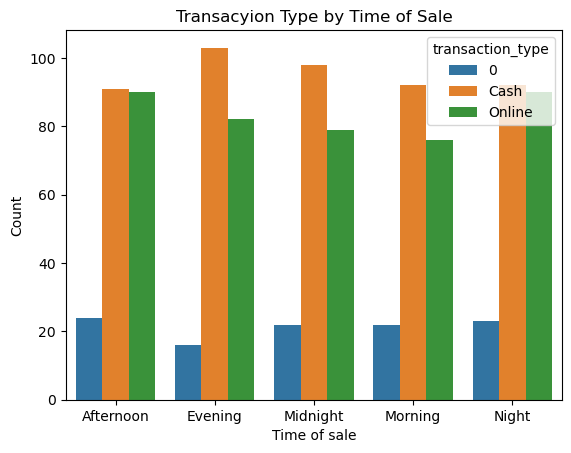

In [153]:
# time_of_sale vs transaction_type
sns.countplot(x='time_of_sale', hue ='transaction_type', data=df)
plt.title("Transacyion Type by Time of Sale")
plt.xlabel("Time of sale")
plt.ylabel("Count")
plt.show()

In [154]:
pd.crosstab(df['time_of_sale'], df['transaction_type'])

transaction_type,0,Cash,Online
time_of_sale,,,
Afternoon,24,91,90
Evening,16,103,82
Midnight,22,98,79
Morning,22,92,76
Night,23,92,90


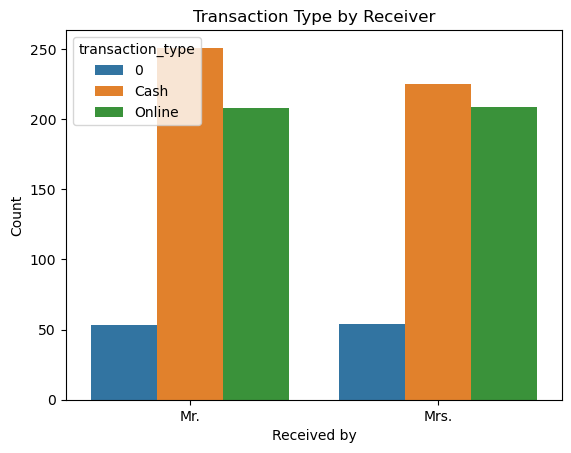

In [43]:
# received_by vs transaction_type
sns.countplot(x='received_by', hue ='transaction_type', data=df)
plt.title("Transaction Type by Receiver")
plt.xlabel("Received by")
plt.ylabel("Count")
plt.show()